# [Super AI Engineer Season 6] Hackathon Week 4
## 5 Domains Hackathon: House Recognition

**Super AI Engineer Season 6 - Level 1 Hackathon**  
- Dataset: Image Processing House Recognition
- จัดทำโดย: 600425-วิศิษฐ์

---
### Notebook Outline
1. Setup & Imports  
2. Data Loading & Initial Inspection  
3. Custom Transforms & Data Augmentation  
4. Model Preparation & Training  
5. Evaluation & Analysis  
6. Prediction & Submission Generation

# 1. Setup & Imports
### 1.1 ติดตั้งไลบรารีที่จำเป็น

In [1]:
!pip uninstall timm -y
!pip -q install --pre timm
!pip install fastai -qq

Found existing installation: timm 1.0.25
Uninstalling timm-1.0.25:
  Successfully uninstalled timm-1.0.25
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 39.1 MB/s eta 0:00:00


### 1.2 นำเข้าไลบรารีและตั้งค่าพารามิเตอร์

In [2]:
import timm as timm
import os
import pandas as pd
from tqdm import tqdm
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from fastai.vision.all import *
from fastai.vision.data import ImageDataLoaders, ImageBlock
from fastai.data.block import DataBlock, CategoryBlock
from fastai.data.transforms import RandomSplitter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
from torchvision import transforms, utils

IMG_ROWS = 224
IMG_COLS = 224
NUM_CLASSES = 10
TEST_SIZE = 0.25
RANDOM_STATE = 99
NO_EPOCHS = 50
BATCH_SIZE = 128
CLASS_COUNT = 68
img_size = 224

path = os.getcwd()
train_dir = '/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/train/train'
test_dir = '/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/test/test'

# 2. Data Loading & Initial Inspection
โหลดข้อมูลจากไฟล์ CSV และตรวจสอบความถูกต้องเบื้องต้น

In [3]:
df = pd.read_csv("/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/train.csv")
df = df.sort_values(by="image_name")
df.head()

,image_name,class
1974,ChokChai4_img_13-7955799_100-6031141_a187-21598902886774_s270_y0_f90_1.jpg,1
1975,ChokChai4_img_13-7956791_100-6031267_a187-21598902886774_s270_y0_f90_1.jpg,1
0,ChokChai4_img_13-7956791_100-6031267_a187-21598902886774_s90_y0_f90_1.jpg,0
1,ChokChai4_img_13-7961753_100-6031881_a185-978546002526_s90_y0_f90_1.jpg,0
2,ChokChai4_img_13-7969811_100-5906061_a180-5812875399312_s270_y0_f90_1.jpg,0


In [4]:
new_train_dir = os.listdir(train_dir)
new_train_dir.sort()
new_train_dir[1:10]

['ChokChai4_img_13-7955799_100-6031141_a187-21598902886774_s270_y0_f90_1.jpg',
 'ChokChai4_img_13-7956791_100-6031267_a187-21598902886774_s270_y0_f90_1.jpg',
 'ChokChai4_img_13-7956791_100-6031267_a187-21598902886774_s90_y0_f90_1.jpg',
 'ChokChai4_img_13-7961753_100-6031881_a185-978546002526_s90_y0_f90_1.jpg',
 'ChokChai4_img_13-7969811_100-5906061_a180-5812875399312_s270_y0_f90_1.jpg',
 'ChokChai4_img_13-7970811_100-5906071_a180-5812875399312_s90_y0_f90_1.jpg',
 'ChokChai4_img_13-7971811_100-5906081_a180-5812875399312_s90_y0_f90_1.jpg',
 'ChokChai4_img_13-7972811_100-5906092_a180-5812875399312_s90_y0_f90_1.jpg',
 'ChokChai4_img_13-7973811_100-5906102_a180-5812875399312_s270_y0_f90_1.jpg']

# 3. Custom Transforms & Data Augmentation
การสร้าง Transform พิเศษสำหรับการปรับแต่งรูปภาพเพิ่ม Contrast และลบส่วนขอบฟ้า (Sky) ที่ไม่จำเป็น

In [5]:
class ContrastEdgeGreenTransform(Transform):
    "Enhances contrast using an S‑curve, blends in Canny edges, and boosts the green channel."
    def __init__(self, k:float=5, edge_weight:float=0.3, canny_thresh1:int=100, canny_thresh2:int=200):
        self.k = k
        self.edge_weight = edge_weight
        self.canny_thresh1 = canny_thresh1
        self.canny_thresh2 = canny_thresh2
        # Build LUT for contrast enhancement via an S‑curve.
        self.lut = np.array([255/(1+np.exp(-self.k*(i/255.0-0.5))) for i in range(256)], dtype=np.uint8)
    
    def encodes(self, img:PILImage):
        # Convert to numpy (RGB)
        im = np.array(img)
        # Apply LUT to boost contrast.
        im_contrast = cv2.LUT(im, self.lut)
        # Get grayscale image for edge detection.
        im_gray = cv2.cvtColor(im_contrast, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(im_gray, self.canny_thresh1, self.canny_thresh2)
        # Convert single channel edge map to 3 channels.
        edges_3ch = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
        # Blend the edge map with the contrast-enhanced image.
        im_blend = cv2.addWeighted(im_contrast, 1.0, edges_3ch, self.edge_weight, 0)
        return PILImage.create(im_blend)

class ForegroundEnhanceTransform(Transform):
    def __init__(self, radial_strength:float=2, crop_sky:bool=True, crop_fraction:float=0.15, blue_threshold:float=80):
        self.radial_strength = radial_strength
        self.crop_sky = crop_sky
        self.crop_fraction = crop_fraction
        self.blue_threshold = blue_threshold
    
    def encodes(self, img:PILImage):
        im = np.array(img)
        h, w, _ = im.shape
        
        # Create a radial mask: center (assumed foreground) has weight ~1, edges ~0.
        y, x = np.ogrid[:h, :w]
        center_y, center_x = h/2, w/2
        distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        max_dist = np.sqrt(center_x**2 + center_y**2)
        norm_distance = distance / max_dist
        mask = 1 - norm_distance**self.radial_strength
        mask = np.clip(mask, 0, 1)[..., np.newaxis]
        
        # Create a strongly blurred version of the image.
        blurred = cv2.GaussianBlur(im, (21, 21), 0)
        # Blend original and blurred images using the radial mask.
        im_blended = (im * mask + blurred * (1 - mask)).astype(np.uint8)
        
        # If enabled, check the top region for excessive sky and crop if detected.
        if self.crop_sky:
            crop_height = int(h * self.crop_fraction)
            top_region = im_blended[:crop_height, :, :]
            avg_blue = top_region[..., 2].mean()
            avg_red = top_region[..., 0].mean()
            avg_green = top_region[..., 1].mean()
            if avg_blue > self.blue_threshold and avg_blue > avg_red + 10 and avg_blue > avg_green + 10:
                im_cropped = im_blended[crop_height:, :, :]
                im_blended = cv2.resize(im_cropped, (w, h), interpolation=cv2.INTER_LINEAR)
        
        return PILImage.create(im_blended)

### 3.1 DataBlock Integration
นำ Transforms ที่กำหนดมาผนวกเข้ากับ DataBlock สำหรับ Training pipeline

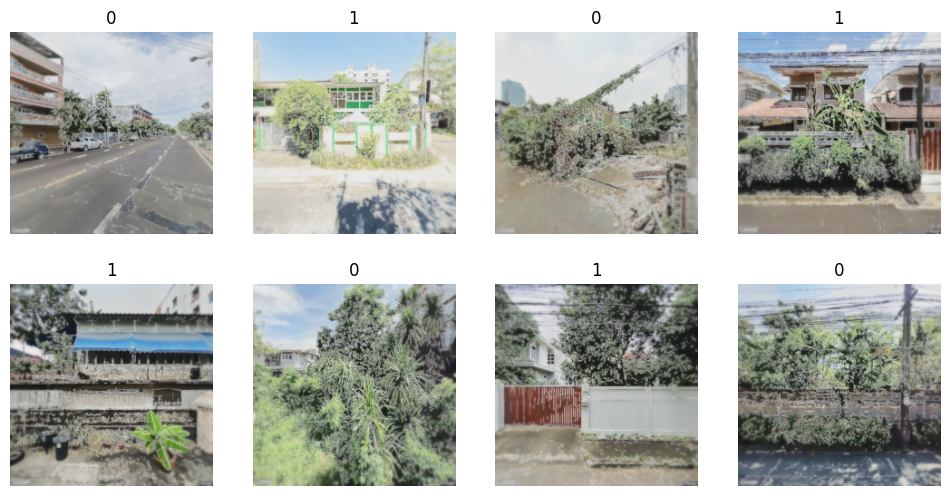

In [6]:
datablock2 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    splitter=RandomSplitter(seed=42),
    get_x=lambda row: os.path.join(train_dir, row['image_name']),
    get_y=lambda row: row['class'],
    item_tfms=[
        ContrastEdgeGreenTransform(k=5, edge_weight=5, canny_thresh1=100, canny_thresh2=200),
        ForegroundEnhanceTransform(radial_strength=1, crop_sky=True, crop_fraction=0.15, blue_threshold=70),
        ToTensor(),
        Resize(img_size)
    ],
    batch_tfms=Normalize.from_stats(*imagenet_stats)
)

dls2 = datablock2.dataloaders(df, seed=123, bs=64)
dls2.train.show_batch(max_n=8)

In [7]:
dls2.vocab

[np.int64(0), np.int64(1)]

# 4. Model Preparation & Training
การเตรียม pre-trained model และเริ่ม Train

In [8]:
avail_pretrained_models = timm.list_models("*eva*", pretrained=True)
print(len(avail_pretrained_models))
avail_pretrained_models[:]

model_name = "eva02_base_patch14_224.mim_in22k"

31


In [9]:
save_cb = SaveModelCallback(monitor="valid_loss", at_end=False, every_epoch=True)
early_stop_cb = EarlyStoppingCallback(monitor="valid_loss", min_delta=0.001, patience=10)
callbacks = [save_cb, early_stop_cb]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,accuracy,time
0,0.534446,0.165259,0.940678,01:25
1,0.361955,0.109584,0.954237,01:22
2,0.288531,0.128193,0.954237,01:23


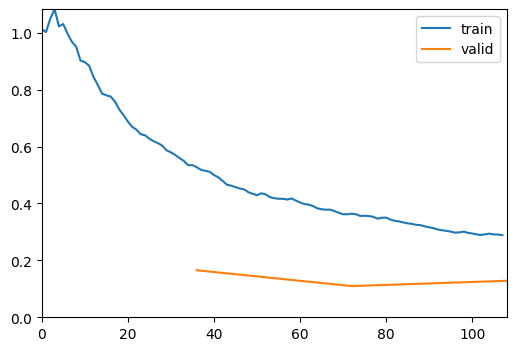

epoch,train_loss,valid_loss,accuracy,time
0,0.158258,0.082774,0.976271,01:22
1,0.108533,0.099190,0.962712,01:23
2,0.091719,0.128343,0.961017,01:22
3,0.082371,0.119363,0.969492,01:22
4,0.053117,0.105443,0.971186,01:31
5,0.037391,0.118220,0.974576,01:35
6,0.025848,0.110739,0.971186,01:34
7,0.016863,0.099304,0.981356,01:33
8,0.012493,0.100437,0.983051,01:33
9,0.010098,0.096203,0.976271,01:30


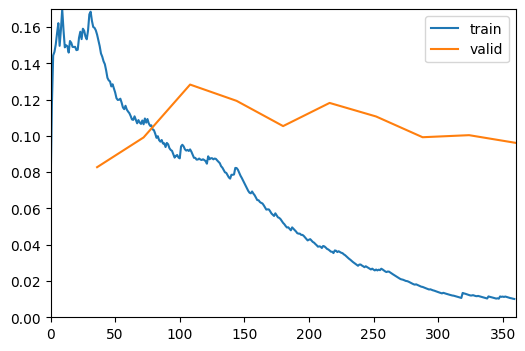

In [10]:
learn = vision_learner(
    dls2, model_name, pretrained=True,
    path="/kaggle/working/",
    cbs=[ShowGraphCallback()],
    metrics=[accuracy]
).to_fp16()

if torch.cuda.device_count() > 1:
    learn.model = torch.nn.DataParallel(learn.model)

learn.fine_tune(10, freeze_epochs=3, cbs=callbacks)

# 5. Evaluation & Analysis
ตรวจสอบผลลัพธ์ของ Model ด้วย Validation set เและตรวจสอบแบบ Confusion Matrix

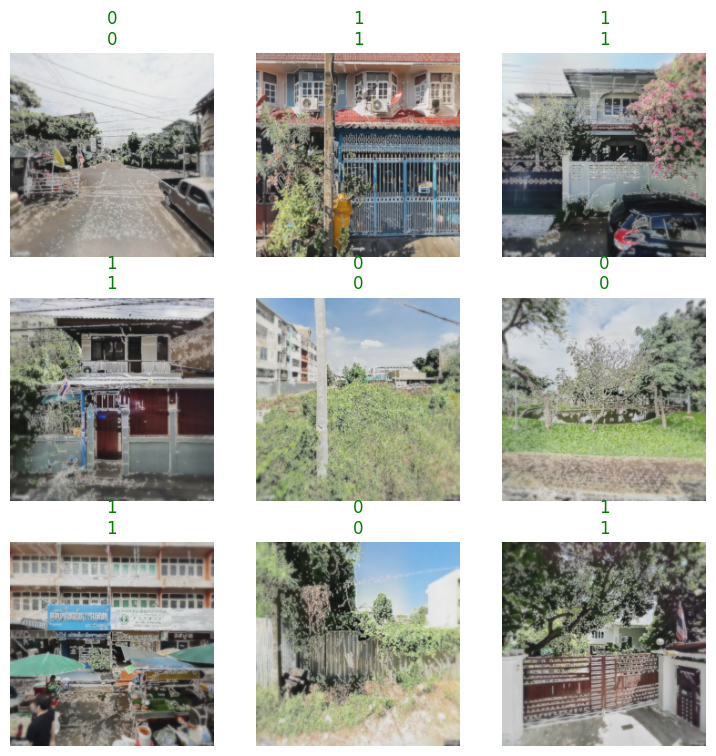

In [11]:
learn.validate()
learn.show_results()

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       303
           1       0.98      0.98      0.98       287

    accuracy                           0.98       590
   macro avg       0.98      0.98      0.98       590
weighted avg       0.98      0.98      0.98       590



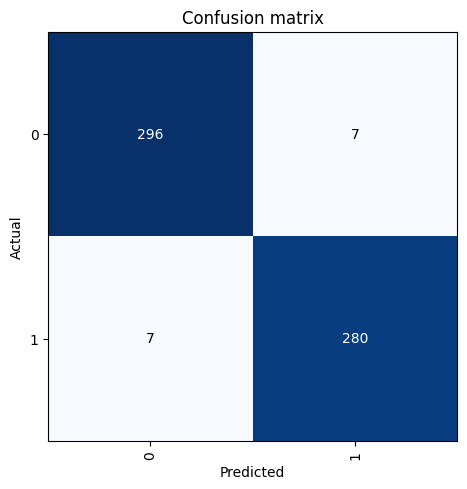

In [12]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.print_classification_report()

Path('/kaggle/working/models/firstmodel.pth')

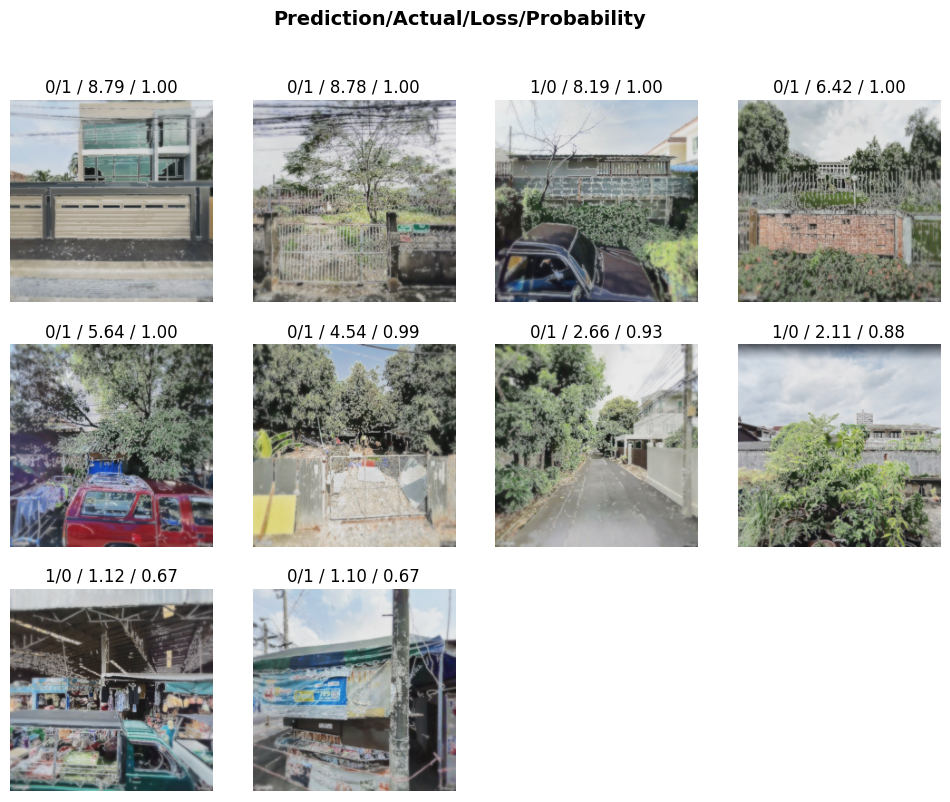

In [13]:
interp.plot_top_losses(k = 10)
learn.save('firstmodel')

# 6. Prediction & Submission Generation
พยากรณ์ผลลัพธ์ในชุดข้อมูล Test set และสร้างไฟล์ Submission สำหรับส่ง Kaggle

In [14]:
submission = pd.read_csv('/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/sample_submission.csv')
submission.head()

,id,answer
0,e4b420b0,0.0
1,23efa479,0.0
2,1f0f2402,0.0
3,8a60480c,NaN
4,11f20127,NaN


In [15]:
df_test=submission.copy()
df_test['id']=test_dir+'/'+df_test['id']+".jpg"
df_test.head()

,id,answer
0,/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/test/test/e4b420b0.jpg,0.0
1,/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/test/test/23efa479.jpg,0.0
2,/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/test/test/1f0f2402.jpg,0.0
3,/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/test/test/8a60480c.jpg,NaN
4,/kaggle/input/competitions/super-ai-engineer-season-6-individual-hackathon-house-recognition/test/test/11f20127.jpg,NaN


In [16]:
test_dl = learn.dls.test_dl(df_test['id'])
preds, decoder = learn.get_preds(dl = test_dl)

labels = preds.argmax(dim=1).tolist()
len(labels)

1550

In [17]:
target_col = 'class' if 'class' in submission.columns else 'answer'
submission[target_col] = labels
submission[target_col] = [dls2.vocab[i] for i in submission[target_col] ]
submission.head()

,id,answer
0,e4b420b0,0
1,23efa479,0
2,1f0f2402,0
3,8a60480c,0
4,11f20127,0


In [18]:
submission.to_csv('5hack_house_recognition.csv', index = False)